<a href="https://colab.research.google.com/github/huangnan52066-code/TsingHuaProjectCode/blob/main/DM_PINN_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Using cached sympy-1.11.1-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.11.1-py3-none-any.whl (6.5 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0+cu128 requires sympy>=1.13.3, but you have sympy 1.11.1 which is incompatible.
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.11.1
    Uninstalling sympy-1.11.1:
      Successfully uninstalled sympy-1.11.1

===== Strat Training Standard PINN =====
[    0] Standard PINN | Total:5.988641 PDE:0.000828
[ 1000] Standard PINN | Total:0.365809 PDE:0.246773
[ 2000] Standard PINN | Total:0.261200 PDE:0.211108
[ 300

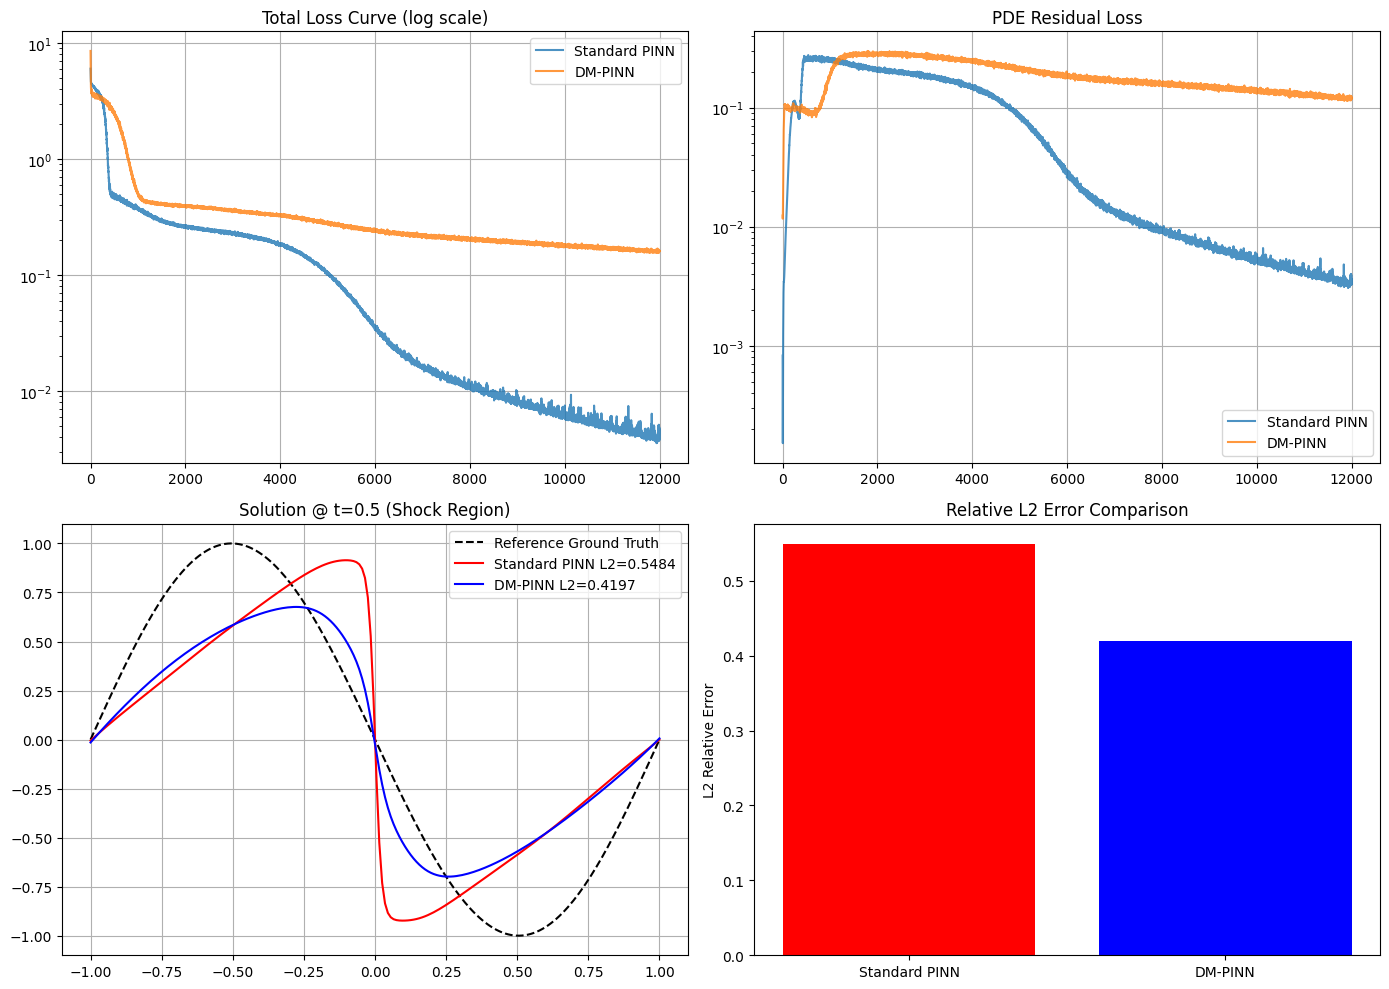


===== Accurancy result =====
Standard PINN Related L2 error: 0.548430
DM-PINN relarted L2 error: 0.419668
DM-PINN Accuracy increase multiplier: 1.31x


In [1]:
!pip install sympy==1.11.1
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# -------------------------- Paramemters --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nu = 0.01
lr = 1e-4
total_epoch = 12000
N_colloc = 10000  # PDE Collocation Points
N_ic = 200        # initial point
N_bc = 100        # Boundary Point
modal_num = 30

# -------------------------- Get Sampling data --------------------------
def sample_collocation(n):
    x = torch.rand(n, 1, device=device) * 2 - 1
    t = torch.rand(n, 1, device=device)
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad = True
    return xt

def sample_ic(n):
    x = torch.linspace(-1, 1, n, device=device).unsqueeze(1)
    t = torch.zeros_like(x, device=device)
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad = True
    u_true = -torch.sin(np.pi * x)
    return xt, u_true

def sample_bc(n):
    t = torch.rand(n, 1, device=device)
    x_left = -torch.ones_like(t)
    x_right = torch.ones_like(t)
    xt_left = torch.cat([x_left, t], dim=1)
    xt_right = torch.cat([x_right, t], dim=1)
    xt_left.requires_grad = True
    xt_right.requires_grad = True
    return xt_left, xt_right

# -------------------------- 1. Standard full-connect PINN --------------------------
class StandardPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
    def forward(self, xt):
        return self.net(xt)
    def get_deriv(self, xt):
        u = self.forward(xt)
        grad = torch.autograd.grad(u.sum(), xt, create_graph=True)[0]
        ux, ut = grad[:,0:1], grad[:,1:2]
        uxx = torch.autograd.grad(ux.sum(), xt, create_graph=True)[0][:,0:1]
        return u, ux, ut, uxx

# -------------------------- 2. DM-PINN structure --------------------------
class DMPINN(nn.Module):
    def __init__(self, modal_k=30):
        super().__init__()
        self.modal_k = modal_k

        self.coeff_net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, modal_k)
        )

        self.space_modal = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, modal_k)
        )

        self.corr_mlp = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, xt):
        x, t = xt[:,0:1], xt[:,1:2]

        coeff = self.coeff_net(t)       # [N, K]
        space_psi = self.space_modal(x) # [N, K]
        modal_part = torch.sum(coeff * space_psi, dim=1, keepdim=True)

        corr_part = self.corr_mlp(xt)
        return modal_part + corr_part
    def get_deriv(self, xt):
        u = self.forward(xt)
        grad = torch.autograd.grad(u.sum(), xt, create_graph=True)[0]
        ux, ut = grad[:,0:1], grad[:,1:2]
        uxx = torch.autograd.grad(ux.sum(), xt, create_graph=True)[0][:,0:1]
        return u, ux, ut, uxx

# -------------------------- Loss function --------------------------
def compute_total_loss(model, xt_col, xt_ic, u_ic_true, xt_bc_l, xt_bc_r):
    # 1. Ic Loss
    u_ic_pred, _, _, _ = model.get_deriv(xt_ic)
    loss_ic = torch.mean((u_ic_pred - u_ic_true)**2)
    # 2. Bc Loss
    u_l, _, _, _ = model.get_deriv(xt_bc_l)
    u_r, _, _, _ = model.get_deriv(xt_bc_r)
    loss_bc = torch.mean(u_l**2) + torch.mean(u_r**2)
    # 3. PDE Physical Residual Loss
    u_col, ux, ut, uxx = model.get_deriv(xt_col)
    residual = ut + u_col * ux - nu * uxx
    loss_pde = torch.mean(residual**2)
    # Weight
    loss_total = 10 * loss_ic + 10 * loss_bc + 1.0 * loss_pde
    return loss_total, loss_ic, loss_bc, loss_pde

# -------------------------- Training function --------------------------
def train_model(model, name):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_hist = {"total":[], "ic":[], "bc":[], "pde":[]}
    print(f"\n===== Strat Training {name} =====")
    for epoch in range(total_epoch):

        xt_col = sample_collocation(N_colloc)
        xt_ic, u_ic_gt = sample_ic(N_ic)
        xt_bc_l, xt_bc_r = sample_bc(N_bc)

        opt.zero_grad()
        loss_t, loss_i, loss_b, loss_p = compute_total_loss(model, xt_col, xt_ic, u_ic_gt, xt_bc_l, xt_bc_r)
        loss_t.backward()
        opt.step()

        loss_hist["total"].append(loss_t.item())
        loss_hist["ic"].append(loss_i.item())
        loss_hist["bc"].append(loss_b.item())
        loss_hist["pde"].append(loss_p.item())

        if epoch % 1000 == 0:
            print(f"[{epoch:5d}] {name} | Total:{loss_t.item():.6f} PDE:{loss_p.item():.6f}")
    return model, loss_hist

# -------------------------- L2 loss --------------------------
def compute_L2_error(model):

    x_test = torch.linspace(-1, 1, 200, device=device).unsqueeze(1)
    t_test = torch.full_like(x_test, 0.5)
    xt_test = torch.cat([x_test, t_test], dim=1)
    u_pred = model(xt_test).detach().cpu().numpy()

    x_np = x_test.cpu().numpy()
    t_np = 0.5
    u_ref = -np.sin(np.pi*x_np) / (1 + np.pi*nu*t_np*np.cos(np.pi*x_np))
    l2_err = np.linalg.norm(u_pred - u_ref) / np.linalg.norm(u_ref)
    return l2_err, x_test.cpu().numpy(), u_pred, u_ref

# -------------------------- Plot --------------------------
def plot_compare(std_loss, dm_loss, std_model, dm_model):
    fig, axes = plt.subplots(2, 2, figsize=(14,10))

    ax1 = axes[0,0]
    ax1.plot(std_loss["total"], label="Standard PINN", alpha=0.8)
    ax1.plot(dm_loss["total"], label="DM-PINN", alpha=0.8)
    ax1.set_yscale("log")
    ax1.set_title("Total Loss Curve (log scale)")
    ax1.legend()
    ax1.grid()

    ax2 = axes[0,1]
    ax2.plot(std_loss["pde"], label="Standard PINN", alpha=0.8)
    ax2.plot(dm_loss["pde"], label="DM-PINN", alpha=0.8)
    ax2.set_yscale("log")
    ax2.set_title("PDE Residual Loss")
    ax2.legend()
    ax2.grid()

    l2_std, x, u_std, ref = compute_L2_error(std_model)
    l2_dm, _, u_dm, _ = compute_L2_error(dm_model)
    ax3 = axes[1,0]
    ax3.plot(x, ref, "k--", label="Reference Ground Truth")
    ax3.plot(x, u_std, "r", label=f"Standard PINN L2={l2_std:.4f}")
    ax3.plot(x, u_dm, "b", label=f"DM-PINN L2={l2_dm:.4f}")
    ax3.set_title(f"Solution @ t=0.5 (Shock Region)")
    ax3.legend()
    ax3.grid()

    ax4 = axes[1,1]
    names = ["Standard PINN", "DM-PINN"]
    errs = [l2_std, l2_dm]
    ax4.bar(names, errs, color=["red", "blue"])
    ax4.set_title("Relative L2 Error Comparison")
    ax4.set_ylabel("L2 Relative Error")
    plt.tight_layout()
    plt.show()
    print(f"\n===== Accurancy result =====")
    print(f"Standard PINN Related L2 error: {l2_std:.6f}")
    print(f"DM-PINN relarted L2 error: {l2_dm:.6f}")
    print(f"DM-PINN Accuracy increase multiplier: {l2_std/l2_dm:.2f}x")

# -------------------------- Main --------------------------
if __name__ == "__main__":

    standard_pinn = StandardPINN().to(device)
    dm_pinn = DMPINN(modal_k=modal_num).to(device)


    std_trained, std_loss_hist = train_model(standard_pinn, "Standard PINN")
    dm_trained, dm_loss_hist = train_model(dm_pinn, "DM-PINN")
    plot_compare(std_loss_hist, dm_loss_hist, std_trained, dm_trained)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nu = 0.01 / np.pi
lr = 1e-3
total_epoch = 12000
hidden_dim = 80
layer_num = 6
N_col = 10000
N_ic = 100
N_bc = 200

def lhs_sampling(n, dim):
    samples = torch.zeros(n, dim, device=device)
    for d in range(dim):
        perm = torch.randperm(n, device=device)
        grid = (torch.arange(n, device=device) + torch.rand(n, device=device)) / n
        samples[:, d] = grid[perm]
    return samples

def sample_collocation():
    xt = lhs_sampling(N_col, 2)
    xt[:, 0] = xt[:, 0] * 2 - 1
    xt[:, 1] = xt[:, 1] * 1
    xt.requires_grad = True
    return xt

def sample_ic():
    x = torch.linspace(-1, 1, N_ic, device=device).unsqueeze(1)
    t = torch.zeros_like(x)
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad = True
    u_gt = -torch.sin(np.pi * x)
    return xt, u_gt

def sample_bc():
    t = lhs_sampling(N_bc, 1)
    xl = -torch.ones_like(t)
    xr = torch.ones_like(t)
    xt_l = torch.cat([xl, t], dim=1)
    xt_r = torch.cat([xr, t], dim=1)
    xt_l.requires_grad = True
    xt_r.requires_grad = True
    return xt_l, xt_r

class VanillaPINN(nn.Module):
    def __init__(self, in_dim=2, hid=80, layers=6):
        super().__init__()
        self.act = nn.Tanh()
        self.layers = nn.ModuleList([nn.Linear(in_dim, hid)] + [nn.Linear(hid, hid) for _ in range(layers-1)])
        self.out = nn.Linear(hid, 1)
    def forward(self, x):
        for layer in self.layers:
            x = self.act(layer(x))
        return self.out(x)
    def get_deriv(self, xt):
        u = self.forward(xt)
        grad = torch.autograd.grad(u.sum(), xt, create_graph=True)[0]
        ux, ut = grad[:,0:1], grad[:,1:2]
        uxx = torch.autograd.grad(ux.sum(), xt, create_graph=True)[0][:,0:1]
        return u, ux, ut, uxx

class DMPINN(nn.Module):
    def __init__(self, in_dim=2, hid=80, layers=6):
        super().__init__()
        self.act = nn.Tanh()
        self.fcs = nn.ModuleList([nn.Linear(in_dim, hid)] + [nn.Linear(hid, hid) for _ in range(layers-1)])
        self.out = nn.Linear(hid, 1)
    def forward(self, x):
        h_list = []
        for fc in self.fcs:
            input_data = x if len(h_list) == 0 else h_list[-1]
            h = self.act(fc(input_data))
            if len(h_list) > 0:
                h = h * h_list[-1] + h
            h_list.append(h)
        return self.out(h_list[-1])
    def get_deriv(self, xt):
        u = self.forward(xt)
        grad = torch.autograd.grad(u.sum(), xt, create_graph=True)[0]
        ux, ut = grad[:,0:1], grad[:,1:2]
        uxx = torch.autograd.grad(ux.sum(), xt, create_graph=True)[0][:,0:1]
        return u, ux, ut, uxx

def compute_loss(model, xt_col, xt_ic, u_ic_gt, xt_bc_l, xt_bc_r):
    u_ic,_,_,_ = model.get_deriv(xt_ic)
    loss_ic = torch.mean((u_ic - u_ic_gt)**2)
    ul,_,_,_ = model.get_deriv(xt_bc_l)
    ur,_,_,_ = model.get_deriv(xt_bc_r)
    loss_bc = torch.mean(ul**2) + torch.mean(ur**2)
    u,ux,ut,uxx = model.get_deriv(xt_col)
    res = ut + u * ux - nu * uxx
    loss_r = torch.mean(res**2)
    return loss_ic + loss_bc + loss_r, loss_ic, loss_bc, loss_r

def train_model(model, name):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_hist = {'total': [], 'residual': [], 'ic': [], 'bc': []}
    for epoch in range(total_epoch):
        xt_col, (xt_ic, u_ic_gt), (xt_bc_l, xt_bc_r) = sample_collocation(), sample_ic(), sample_bc()
        opt.zero_grad()
        loss_t, loss_ic, loss_bc, loss_r = compute_loss(model, xt_col, xt_ic, u_ic_gt, xt_bc_l, xt_bc_r)
        loss_t.backward()
        opt.step()

        loss_hist['total'].append(loss_t.item())
        loss_hist['residual'].append(loss_r.item())
        loss_hist['ic'].append(loss_ic.item())
        loss_hist['bc'].append(loss_bc.item())

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | {name:12s} Loss:{loss_t.item():.6f} BC:{loss_bc.item():.6f} PDE:{loss_r.item():.6f}")
    return model, loss_hist

if __name__ == "__main__":
    m1, std_loss = train_model(VanillaPINN().to(device), "Vanilla")
    print("=====================================")
    m2, dm_loss = train_model(DMPINN().to(device), "DM-PINN")

Epoch     0 | Vanilla      Loss:0.537904 BC:0.029961 PDE:0.000123
Epoch  1000 | Vanilla      Loss:0.091661 BC:0.000839 PDE:0.035582
Epoch  2000 | Vanilla      Loss:0.044834 BC:0.000358 PDE:0.019822
Epoch  3000 | Vanilla      Loss:0.007805 BC:0.000583 PDE:0.005172
Epoch  4000 | Vanilla      Loss:0.001741 BC:0.000114 PDE:0.001204
Epoch  5000 | Vanilla      Loss:0.001924 BC:0.000068 PDE:0.001363
Epoch  6000 | Vanilla      Loss:0.002406 BC:0.000105 PDE:0.002204
Epoch  7000 | Vanilla      Loss:0.000578 BC:0.000029 PDE:0.000455
Epoch  8000 | Vanilla      Loss:0.000528 BC:0.000032 PDE:0.000416
Epoch  9000 | Vanilla      Loss:0.000404 BC:0.000022 PDE:0.000320
Epoch 10000 | Vanilla      Loss:0.000262 BC:0.000032 PDE:0.000196
Epoch 11000 | Vanilla      Loss:0.000368 BC:0.000178 PDE:0.000135
Epoch     0 | DM-PINN      Loss:0.504677 BC:0.008227 PDE:0.001106
Epoch  1000 | DM-PINN      Loss:0.002858 BC:0.000041 PDE:0.001984
Epoch  2000 | DM-PINN      Loss:0.000532 BC:0.000027 PDE:0.000310
Epoch  300

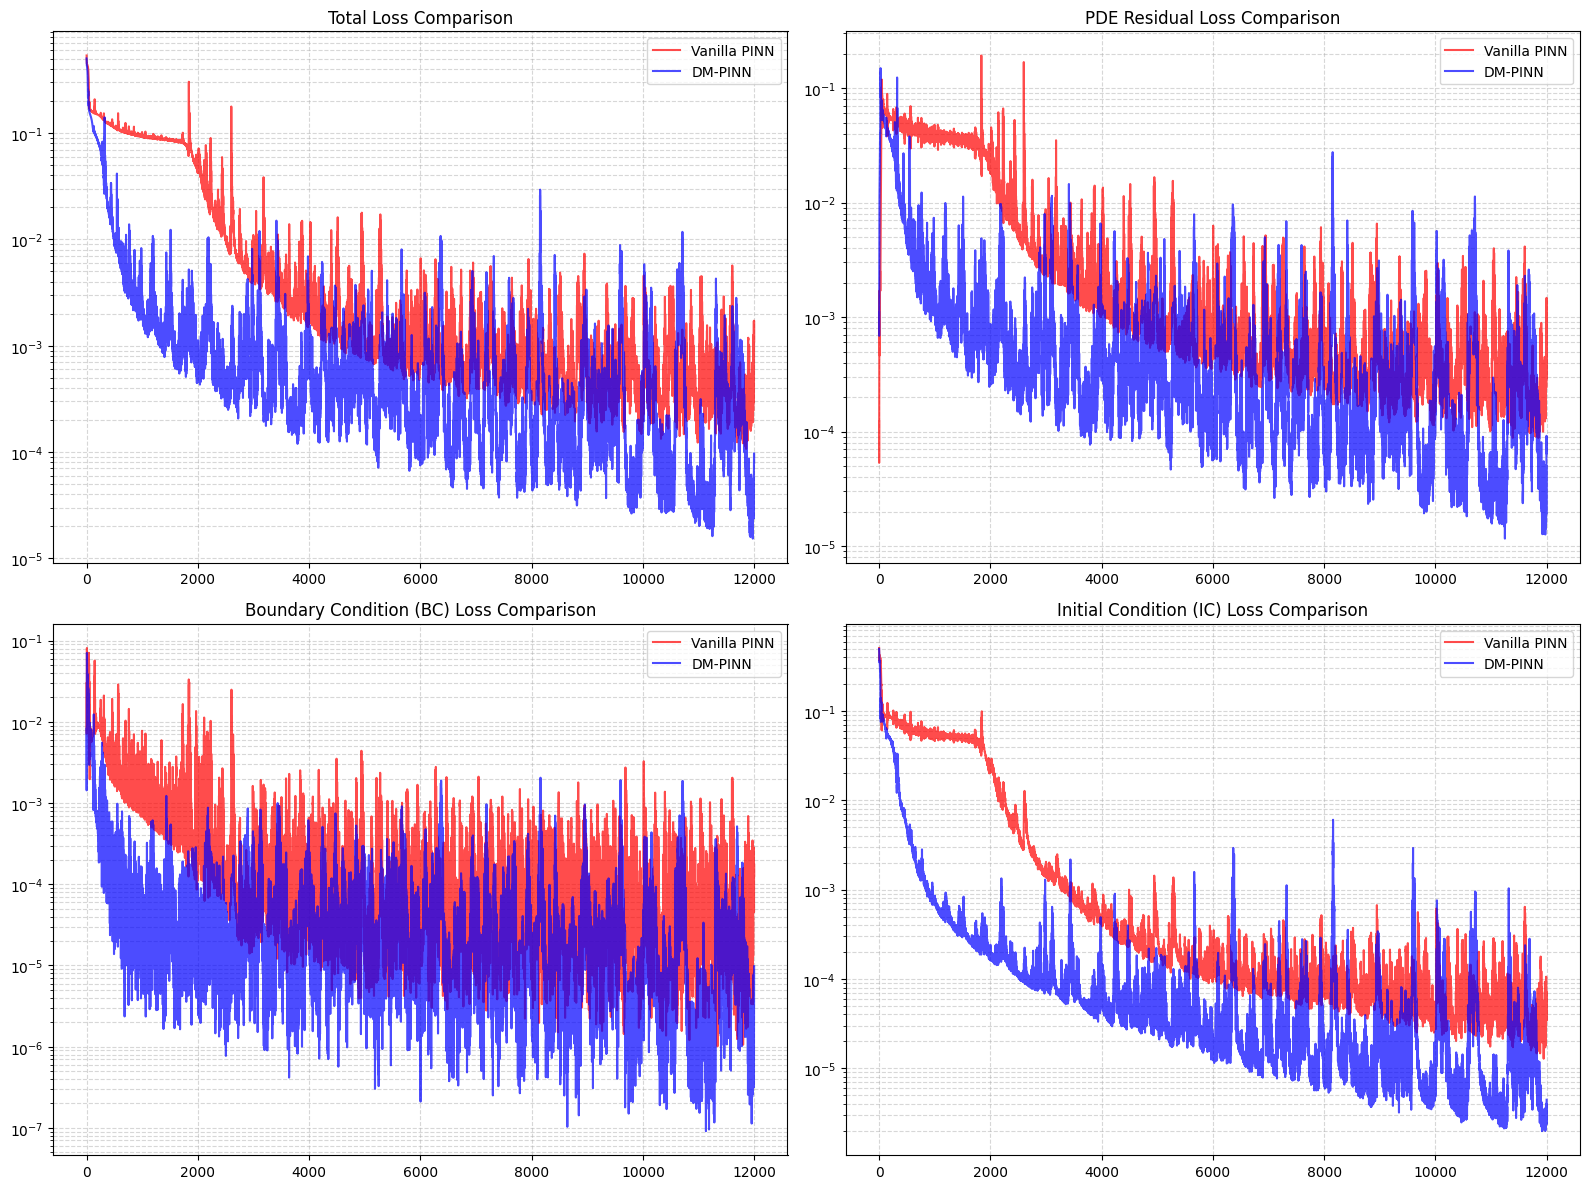

In [3]:
import matplotlib.pyplot as plt

if 'std_loss' in globals() and 'dm_loss' in globals():
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Total Loss
    axes[0,0].plot(std_loss['total'], label='Vanilla PINN', alpha=0.7, color='red')
    axes[0,0].plot(dm_loss['total'], label='DM-PINN', alpha=0.7, color='blue')
    axes[0,0].set_yscale('log')
    axes[0,0].set_title('Total Loss Comparison')
    axes[0,0].legend(); axes[0,0].grid(True, which="both", ls="--", alpha=0.5)

    # 2. PDE Residual Loss
    axes[0,1].plot(std_loss['residual'], label='Vanilla PINN', alpha=0.7, color='red')
    axes[0,1].plot(dm_loss['residual'], label='DM-PINN', alpha=0.7, color='blue')
    axes[0,1].set_yscale('log')
    axes[0,1].set_title('PDE Residual Loss Comparison')
    axes[0,1].legend(); axes[0,1].grid(True, which="both", ls="--", alpha=0.5)

    # 3. Boundary Condition Loss
    axes[1,0].plot(std_loss['bc'], label='Vanilla PINN', alpha=0.7, color='red')
    axes[1,0].plot(dm_loss['bc'], label='DM-PINN', alpha=0.7, color='blue')
    axes[1,0].set_yscale('log')
    axes[1,0].set_title('Boundary Condition (BC) Loss Comparison')
    axes[1,0].legend(); axes[1,0].grid(True, which="both", ls="--", alpha=0.5)

    # 4. Initial Condition Loss
    axes[1,1].plot(std_loss['ic'], label='Vanilla PINN', alpha=0.7, color='red')
    axes[1,1].plot(dm_loss['ic'], label='DM-PINN', alpha=0.7, color='blue')
    axes[1,1].set_yscale('log')
    axes[1,1].set_title('Initial Condition (IC) Loss Comparison')
    axes[1,1].legend(); axes[1,1].grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("please Training network first UqtHqpOq2xql。")